# ANOVA

In [21]:
# Numerical arrays.
import numpy as np

# Plotting.
import matplotlib.pyplot as plt

# Statistical functions.
import scipy.stats as stats

# Mathematical functions.
import math

# Data frames.
import pandas as pd

# Combinations and permutations.
import itertools as it

## More Samples

In [22]:
# First sample.
sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)

# Second sample.
sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)

# Third sample.
sample_c = np.random.normal(loc=10.0, scale=1.0, size=50)

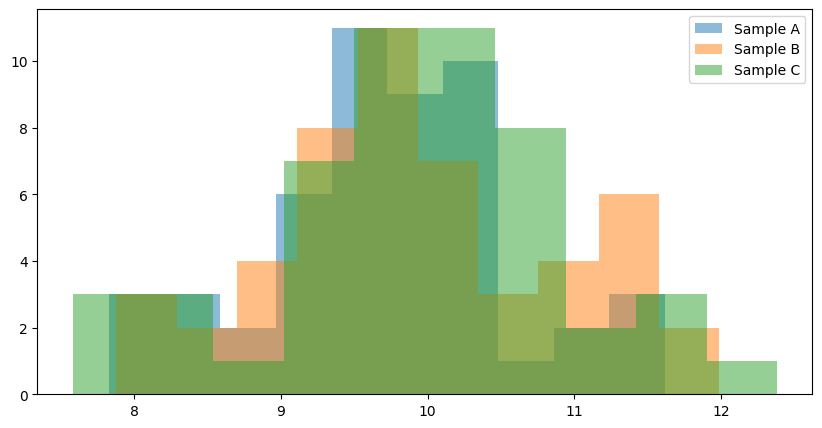

In [23]:
# Create histograms.
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of the first sample.
ax.hist(sample_a, bins=10, alpha=0.5, label='Sample A')

# Histogram of the second sample.
ax.hist(sample_b, bins=10, alpha=0.5, label='Sample B')

# Histogram of the third sample.
ax.hist(sample_c, bins=10, alpha=0.5, label='Sample C')

# Add a legend.
ax.legend();

In [24]:
# Independent samples t-test on sample_a and sample_b.
t_statistic, p_value = stats.ttest_ind(sample_a, sample_b)

# Show.
t_statistic, p_value

(np.float64(-1.064404732743367), np.float64(0.28976098966242747))

In [25]:
# Independent samples t-test on sample_b and sample_a.
t_statistic, p_value = stats.ttest_ind(sample_b, sample_a)

# Show.
t_statistic, p_value

(np.float64(1.064404732743367), np.float64(0.28976098966242747))

In [26]:
# Independent samples t-test on sample_a and sample_c.
t_statistic, p_value = stats.ttest_ind(sample_a, sample_c)

# Show.
t_statistic, p_value

(np.float64(-1.3125530178438918), np.float64(0.19239928129918046))

In [27]:
# Independent samples t-test on sample_b and sample_c.
t_statistic, p_value = stats.ttest_ind(sample_b, sample_c)

# Show.
t_statistic, p_value

(np.float64(-0.23340519603715112), np.float64(0.8159336213356956))

## $n$ Samples

In [28]:
# Number of samples.
n = 4

In [29]:
# Show the sample labels.
print(list(range(4)))

[0, 1, 2, 3]


For 4 samples, we can perform 6 t-tests:

[0, 1]  
[0, 2]  
[0, 3]  
[1, 2]  
[1, 3]  
[2, 3]  

In [30]:
# Number of ways of selecting two samples from n.
math.comb(n, 2)

6

In [31]:
# Suppose we had 6 samples.
n = 6
math.comb(n, 2)

15

In [32]:
# Suppose we had 7 samples.
n = 7
math.comb(n, 2)

21

## Type I Errors

In [33]:
def simulate_ttest(alpha=0.05):
    # Geneate a random sample a.
    sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample b.
    sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)
    
    # Perform the t-test.
    _, p_value = stats.ttest_ind(sample_a, sample_b)
    
    # Decide whether to reject the null hypothesis.
    if p_value < alpha:
        return True
    else:
        return False

In [34]:
# Number of rejections.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_ttest():
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

489

In [35]:
def simulate_three_ttest(alpha=0.05):
    # Geneate a random sample a.
    sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample b.
    sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample c.
    sample_c = np.random.normal(loc=10.0, scale=1.0, size=50)
    
    # Perform the t-test one.
    _, p_value0 = stats.ttest_ind(sample_a, sample_b)
    _, p_value1 = stats.ttest_ind(sample_a, sample_c)
    _, p_value2 = stats.ttest_ind(sample_b, sample_c)
    
    # Return the number of null hypothesis rejections.
    no_rejections = 0
    if p_value0 < alpha:
      no_rejections += 1
    if p_value1 < alpha:
      no_rejections += 1
    if p_value2 < alpha:
      no_rejections += 1
    
    return no_rejections

In [36]:
# Set no_rejections to zero.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_three_ttest() > 0:
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

1246

In [37]:
# Generate all pairs of integers from 0 to 6.
for i, j in it.combinations(range(7), 2):
  print(f'{i},{j}')

0,1
0,2
0,3
0,4
0,5
0,6
1,2
1,3
1,4
1,5
1,6
2,3
2,4
2,5
2,6
3,4
3,5
3,6
4,5
4,6
5,6


In [38]:
def simulate_multiple_ttest(no_samples=7, alpha=0.05):
    # Geneate no_samples random samples.
    samples = np.random.normal(size=(no_samples, 50))
    
    # Keep track of nubmer of null hypothesis rejections.
    no_rejections = 0

    # Performs all t-tests.
    for i, j in it.combinations(range(no_samples), 2):
      _, p_value = stats.ttest_ind(samples[i], samples[j])
      if p_value < alpha:
        no_rejections += 1
    
    return no_rejections

In [40]:
# Set no_rejections to zero.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_multiple_ttest() > 0:
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

KeyboardInterrupt: 

## ANOVA

https://statistics.laerd.com/spss-tutorials/one-way-anova-using-spss-statistics.php  

In [ ]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

In [ ]:
# Create data frame.
df = pd.DataFrame({'Beginner': beginner, 'Intermediate': intermediate, 'Advanced': advanced})

# Show.
df

,Beginner,Intermediate,Advanced
0,24.368291,17.471705,22.817261
1,27.076825,17.306096,22.954547
2,30.034154,21.585528,24.284620
3,25.750237,25.515119,25.358335
4,28.727654,23.953066,23.891560
5,22.278058,24.376922,27.771785
6,24.724001,21.446582,21.797814
7,29.472133,16.301365,23.468076
8,31.012428,24.392601,20.111976
9,26.297231,25.300625,18.325219


In [ ]:
# Describe.
df.describe()

,Beginner,Intermediate,Advanced
count,10.000000,10.000000,10.000000
mean,26.974101,21.764961,23.078119
std,2.805940,3.549291,2.637546
min,22.278058,16.301365,18.325219
25%,24.980560,18.465424,22.052676
50%,26.687028,22.769297,23.211312
75%,29.286013,24.388682,24.186355
max,31.012428,25.515119,27.771785


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html  

In [ ]:
# Perform ANOVA.
f_statistic, p_value = stats.f_oneway(df['Beginner'], df['Intermediate'], df['Advanced'])

# Show.
f_statistic, p_value

(np.float64(8.028135738613065), np.float64(0.001836196534033126))

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html

In [ ]:
# Tukey's HSD.
res = stats.tukey_hsd(df['Beginner'], df['Intermediate'], df['Advanced'])

# Show.
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      5.209     0.002     1.856     8.562
 (0 - 2)      3.896     0.020     0.543     7.249
 (1 - 0)     -5.209     0.002    -8.562    -1.856
 (1 - 2)     -1.313     0.601    -4.666     2.040
 (2 - 0)     -3.896     0.020    -7.249    -0.543
 (2 - 1)      1.313     0.601    -2.040     4.666



## Presenting the Data

In [ ]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

# Concatenate arrays.
data = np.concatenate([beginner, intermediate, advanced])

# Show.
data

array([27.7837412 , 23.11931431, 27.08788448, 25.59130167, 21.07449118,
       23.67968568, 24.16399557, 26.75273215, 29.02510426, 23.15764142,
       23.99103444, 24.46399957, 23.70519489, 22.38350085, 25.61172914,
       22.89510942, 19.69478034, 18.04926912, 28.95532671, 21.80760624,
       23.17006396, 21.65591372, 21.00077894, 23.66205095, 22.27782822,
       21.26760301, 21.83902461, 25.21649232, 32.46379678, 23.72163305])

In [ ]:
# Create the labels.
labels = ['Beginner'] * 10 + ['Intermediate'] * 10 + ['Advanced'] * 10

# Show.
labels

['Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced']

In [ ]:
# Create data frame.
df = pd.DataFrame({'Course': labels, 'Time': data})

# Show.
df

,Course,Time
0,Beginner,27.783741
1,Beginner,23.119314
2,Beginner,27.087884
3,Beginner,25.591302
4,Beginner,21.074491
5,Beginner,23.679686
6,Beginner,24.163996
7,Beginner,26.752732
8,Beginner,29.025104
9,Beginner,23.157641


In [ ]:
# Pull the groups out.
b_times = df[df['Course'] == 'Beginner']['Time']
i_times = df[df['Course'] == 'Intermediate']['Time']
a_times = df[df['Course'] == 'Advanced']['Time']

# Perform ANOVA.
f, p = stats.f_oneway(b_times, i_times, a_times)

# Show.
f, p

(np.float64(1.2064419598246356), np.float64(0.31488581364881824))

In [ ]:
# Tukey's HSD.
res = stats.tukey_hsd(b_times, i_times, a_times)

# Show.
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      1.988     0.313    -1.328     5.304
 (0 - 2)      1.516     0.502    -1.800     4.832
 (1 - 0)     -1.988     0.313    -5.304     1.328
 (1 - 2)     -0.472     0.934    -3.787     2.844
 (2 - 0)     -1.516     0.502    -4.832     1.800
 (2 - 1)      0.472     0.934    -2.844     3.787



## The F Statistic using numpy

https://en.wikipedia.org/wiki/F-test#One-way_analysis_of_variance

In [ ]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

In [ ]:
# Calculate the means.
beginner_mean = beginner.mean()
intermediate_mean = intermediate.mean()
advanced_mean = advanced.mean()

In [ ]:
# Y(bar)_i from the formula.
Y_i = np.array([beginner_mean, intermediate_mean, advanced_mean])

# Show.
Y_i

array([28.53902013, 22.60666434, 22.83103348])

In [ ]:
# Y(bar) from the formula.
Y = np.concatenate([beginner, intermediate, advanced]).mean()

# Show.
Y

np.float64(24.658905983757528)

In [ ]:
# Before the sum of squares.
Y_i - Y

array([ 3.88011414, -2.05224164, -1.8278725 ])

In [ ]:
# Calculate the sum of squares between.
(Y_i - Y)**2

array([15.05528577,  4.21169575,  3.34111789])

In [ ]:
# Size of the samples.
n_i = np.array([beginner.size, intermediate.size, advanced.size])

# Show.
n_i

array([10, 10, 10])

In [ ]:
# Number of groups.
K = 3

In [ ]:
# From the formula.
n_i * (Y_i - Y)**2

array([150.55285771,  42.11695753,  33.41117887])

In [ ]:
# From the formula.
(n_i * (Y_i - Y)**2).sum()

np.float64(226.08099411334007)

In [ ]:
# From the formula.
(n_i * (Y_i - Y)**2).sum() / (K - 1)

np.float64(113.04049705667003)

In [ ]:
# Numerator.
numerator = (n_i * (Y_i - Y)**2).sum() / (K - 1)

In [ ]:
# The total number of values.
N = n_i.sum()

# Show.
N

np.int64(30)

In [ ]:
# From the formula.
less_means = np.concatenate([beginner - beginner_mean, intermediate - intermediate_mean, advanced - advanced_mean])

# Show.
less_means

array([-0.93499227,  1.40284179, -1.41700901,  1.32509407,  0.39322896,
       -1.31095216,  1.33285233, -2.25450424,  0.93478655,  0.52865397,
        5.98377276, -4.25513522, -4.42960944,  6.42869777, -2.39331023,
        1.2798364 , -4.10336036,  5.48113877, -1.43001981, -2.56201063,
       -2.47916667, -4.0672559 ,  2.59380974, -6.24459623, -2.7210812 ,
        2.64269815,  2.16868081,  4.32296216,  0.51607119,  3.26787794])

In [ ]:
# From the formula.
np.sum(less_means**2)

np.float64(311.34463973878735)

In [ ]:
# Denominator.
denominator = np.sum(less_means**2) / (N - K)

# Show.
denominator

np.float64(11.53128295328842)

In [ ]:
# My F statistic calculation.
F = numerator / denominator

# Show.
F

np.float64(9.802941920216591)

In [ ]:
# Calculate F using scipy.
stats.f_oneway(beginner, intermediate, advanced)

F_onewayResult(statistic=np.float64(9.802941920216574), pvalue=np.float64(0.0006301743362425931))

## End